In [1]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neural_network import MLPClassifier as NN

import math
import matplotlib as mpl
from functools import partial

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.gaussian_process import GaussianProcessClassifier as GPC
from sklearn.gaussian_process.kernels import RBF

from dijsktra_algorithm import Graph, dijsktra_toall
from density_estimator import DensityEstimator


In [2]:
# https://www.python-course.eu/neural_network_mnist.php
image_size = 28 # width and length
no_of_different_labels = 10 #  i.e. 0, 1, 2, 3, ..., 9
image_pixels = image_size * image_size
data_path = "data/mnist_test.csv"
train_data = np.loadtxt(data_path, delimiter=",",skiprows=1)

fac = 0.99 / 255
train_imgs = np.asfarray(train_data[:, 1:]) * fac + 0.01
train_labels = np.asfarray(train_data[:, :1]).ravel()


Define N and M where: 
- N: number of training points to provide counterfactuals
- M: how many counterfactuals per point, randomly drawn from possible classes
- Total number of counterfactuals = N x M

In [11]:
number_a = 3
number_b = 8

In [12]:

indices_a = set(np.where(train_labels == number_a)[0][:1000])
indices_b = set(np.where(train_labels == number_b)[0][:1000])

indices = np.array(list(indices_a.union(indices_b)))

X = train_imgs[indices, :]
y = train_labels[indices]

y[y==number_a]=0
y[y==number_b]=1

In [13]:
def inv_log(x):
    return -np.log(x)

def get_edges(kernel):
    edges = []

    n_samples = kernel.shape[0]
    for i in range(n_samples):
        for j in range(i):
            weight = kernel[i, j]
            if weight != 0 :
                edges.append([i, j, weight])
                #edges.append([str(j), str(i), weight])
    return edges


def get_weights(X, 
                density_scorer, 
                mode,
                weight_func = inv_log):
    epsilon = 0.75
    n_samples, _ = X.shape
    k = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        v0 = X[i, :].reshape(-1, 1)
        for j in range(i):
            v1 = X[j, :].reshape(-1, 1)
            dist = np.linalg.norm(v0 - v1)
            if dist <= epsilon:
                midpoint = (v0 + v1)/2
                density = density_scorer(midpoint.reshape(1, -1))
                if mode == 1:
                    k[i, j] = weight_func(np.exp(density)) * dist
                else:
                    k[i, j] = weight_func(sigmoid(density)) * dist
            else:
                k[i, j] = 0
            k[j, i] = k[i, j]
    return k

def get_weights_kNN(
    X, 
    n_neighbours = 20,
    alpha=0.10,
    weight_func = inv_log
    ):
    n_samples, n_ftrs = X.shape
#     volume_sphere = get_volume_of_sphere(n_ftrs)
#     const = (n_neighbours / (n_samples * volume_sphere))**(1/n_ftrs)
    
    k = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        v0 = X[i, :].reshape(-1, 1)
        for j in range(n_samples):
            v1 = X[j, :].reshape(-1, 1)
            dist = np.linalg.norm(v0 - v1)
            k[i, j] = dist
        t = np.argsort(k[i, :])[(n_neighbours+1):]
        mask = np.ix_(t)
        k[i, mask] = 0
        
    for i in range(n_samples):
        v0 = X[i, :].reshape(-1, 1)
        for j in range(n_samples):
            v1 = X[j, :].reshape(-1, 1)
            if k[i, j] != 0:
                current_value = k[i, j]
#                 k[i, j] = current_value**alpha
                k[i, j] = weight_func(current_value)
    return k

def get_weights_e(X, 
                 epsilon = 0.75,
                 alpha=0.10,
                 weight_func = inv_log):
    n_samples, n_ftrs = X.shape
    k = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        v0 = X[i, :].reshape(-1, 1)
        for j in range(i):
            v1 = X[j, :].reshape(-1, 1)
            dist = np.linalg.norm(v0 - v1)
            if dist <= epsilon:
                k[i, j] = weight_func(current_value)
                k[j, i] = k[i, j]
    return k

In [14]:
clf = NN(max_iter=5000).fit(X, y)

In [15]:
predictions = clf.predict_proba(X)

In [16]:
bandwidths = 10 ** np.linspace(-2, 0, 10)

grid = GridSearchCV(
    KernelDensity(kernel='gaussian'),
    {'bandwidth': bandwidths},
)

grid.fit(X)
kde = grid.best_estimator_

In [17]:
n_neighbours = 20
n_samples, n_features = X.shape

def get_volume_of_sphere(d):
    return math.pi**(d/2)/math.gamma(d/2 + 1)

volume_sphere = get_volume_of_sphere(1)
r = (n_neighbours / (n_samples * volume_sphere))
    
res = {}
for test_index in [0, 10, 20, 30, 50]:
    res[test_index] = {}
    for idx, alpha in enumerate([1]):  # np.linspace(0.01, 3, 9)
    
        kernel = get_weights_kNN(
            X,
            n_neighbours=int(n_neighbours),
            weight_func=lambda x: -x*np.log(r/x)  # x**alpha
        )

        graph = Graph()
        edges = get_edges(kernel)
        for edge in edges:
            graph.add_edge(*edge) 

        dist, paths = dijsktra_toall(graph, test_index)
        for item, val in paths.items():
            if (y[item] != y[test_index] 
                and predictions[item, int(y[item])] >= 0.55):
                res[test_index][idx] = val


In [ ]:
def plot_digits(images,labels, _id):
    if not type(images) is list and not type(labels) is list:
        images = [images]
        labels = [labels]
    
    n_digits = len(images)
    ncols=min(10, n_digits)
    nrows = math.ceil(n_digits / ncols)
    
    _, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4*nrows))
    
    if n_digits>1:
        axes = axes.ravel()
    else:
        axes = [axes]

    for image, label in list(zip(images, labels)):
        ax = axes[idx]
        ax.set_axis_off()
        ax.imshow(image.reshape(28, 28), cmap=plt.cm.gray_r, interpolation="nearest")
        ax.set_title(f"id:{_id}, label: {label}")
    # plt.savefig(f'example_{_id}_log.jpg', dpi=200)

In [ ]:
def plot_counterfactuals(path, _id):
    n_digits = len(path)
    ncols=min(10, n_digits)
    nrows = math.ceil(n_digits / ncols)
    _, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4*nrows))
    
    for idx, img_idx in enumerate(path):
        ax = axes[idx]
        image = X[img_idx, :]
        label = y[img_idx]
        ax.set_axis_off()
        ax.imshow(image.reshape(28, 28), cmap=plt.cm.gray_r, interpolation="nearest")
        ax.set_title(f"id:{_id}, t: {label}")
    plt.savefig(f'example_{_id}_log.jpg', dpi=200)

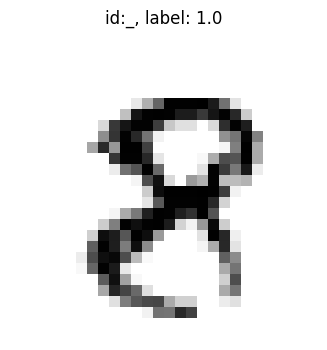

In [42]:
plot_digits(X[10],y[10],'_')

0 0
10 0
20 0
30 0
50 0


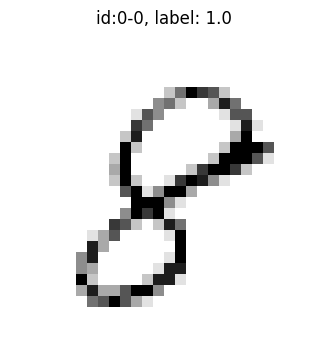

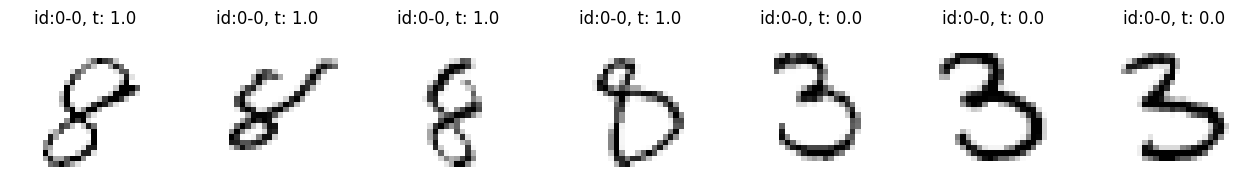

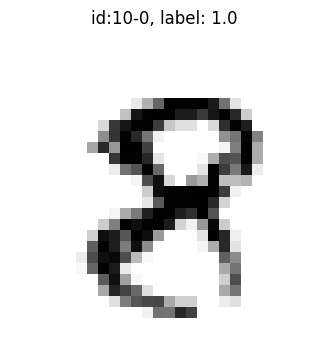

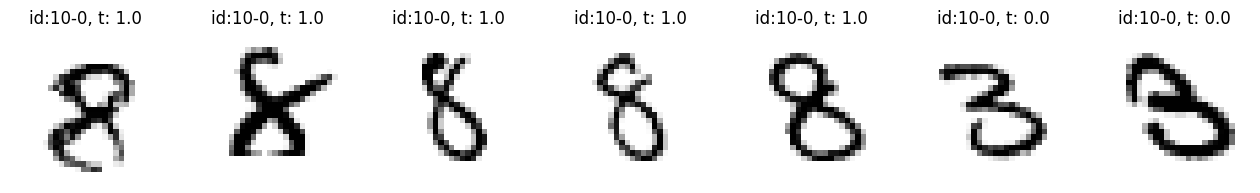

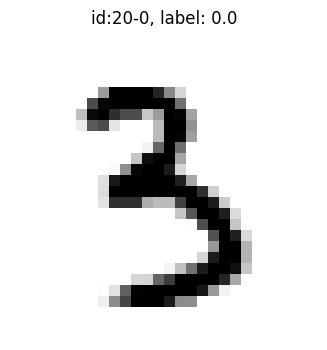

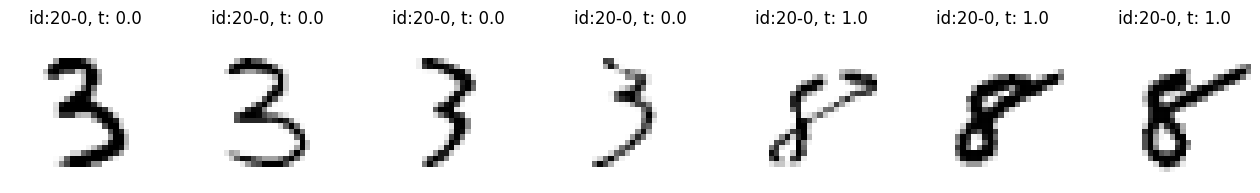

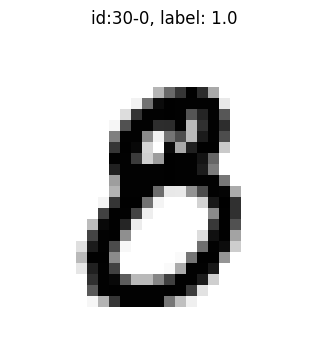

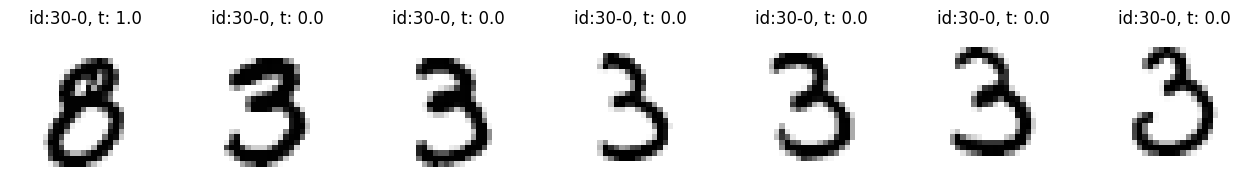

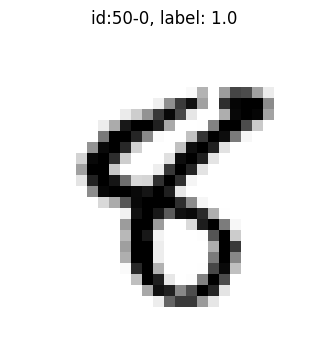

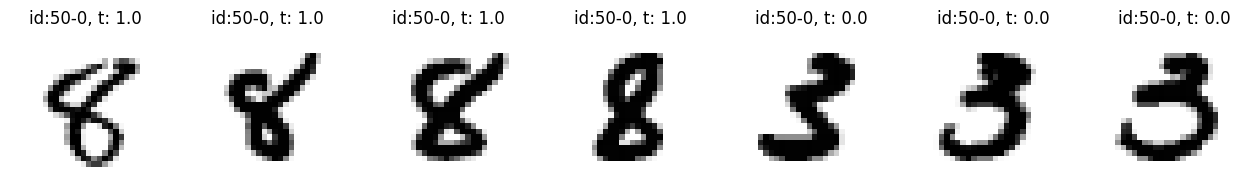

In [43]:
for k in res.keys():
    for k2 in res[k].keys():
        print(k, k2)
        plot_digits(X[k],y[k],'-'.join(map(str, [k, k2])))
        plot_counterfactuals(res[k][k2], '-'.join(map(str, [k, k2])))

NameError: name 'X' is not defined

## Pseudo-code

- train classifier - use density estimation to generate paths

- train second classifier using cf dataset?
    - how to implement loss?
    - clone standard method and add direction loss to loss?


2.0
4.0
8.0
2.0
1.0
7.0
2.0
4.0
9.0
4.0
4.0
0.0
3.0
9.0
2.0
2.0
3.0
3.0
8.0
3.0


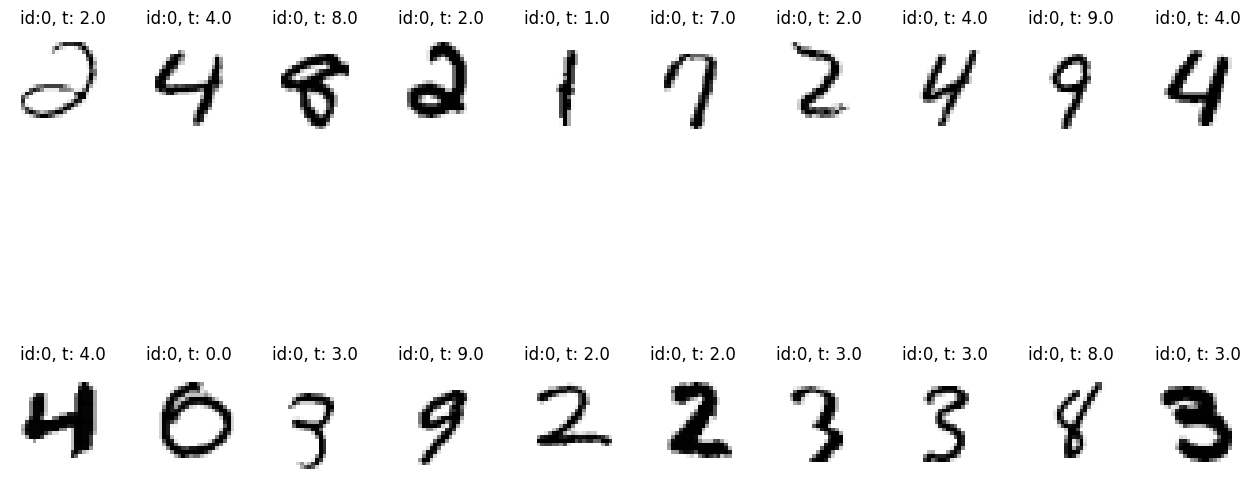

In [73]:
plot_digits(np.arange(1050,1070),0)

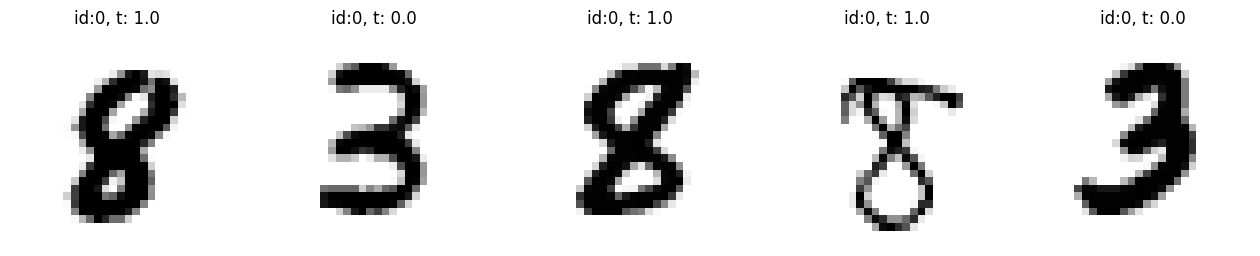

In [60]:
plot_digits(np.arange(1810,1815),0)


In [1]:
train_data[0]

NameError: name 'train_data' is not defined